In [30]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OrdinalEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

In [2]:
d = {'miles_per_week': [37,39,46,51,88,17,18,20,21,22,23,24,25,27,28,29,30,31,32,33,34,38,40,42,57,68,35,36,41,43,45,47,49,50,52,53,54,55,56,58,59,60,61,63,64,65,66,69,70,72,73,75,76,77,78,80,81,82,83,84,85,86,87,89,91,92,93,95,96,97,98,99,100,101,102,103,104,105,106,107,109,110,111,113,114,115,116,116,118,119,120,121,123,124,126,62,67,74,79,90,112],
      'completed_50m_ultra': ['no','no','no','no','no','no','no','no','no','no','no','no','no','no','no','no','no','no','no','no','no','no','no','no','no','no','yes','yes','yes','yes','no','yes','yes','yes','no','yes','yes','yes','yes','yes','yes','yes','yes','no','yes','yes','yes','yes','yes','yes','yes','no','yes','yes','yes','yes','yes','yes','yes','no','yes','yes','yes','yes','yes','yes','yes','no','yes','yes','yes','yes','yes','yes','yes','yes','yes','yes','yes','yes','yes','yes','yes','yes','yes','yes','yes','yes','yes','yes','yes','yes','yes','yes','yes','yes','yes','yes','yes','yes','yes',]}

In [3]:
df = pd.DataFrame(d)
df

,miles_per_week,completed_50m_ultra
0,37,no
1,39,no
2,46,no
3,51,no
4,88,no
...,...,...
96,67,yes
97,74,yes
98,79,yes
99,90,yes


# Encoding Data

In [10]:
finish_race = ['yes', 'no']
ordinal = OrdinalEncoder(categories=[finish_race])

In [12]:
df['completed_50m_ultra'] = ordinal.fit_transform(df[['completed_50m_ultra']])

# Visualization

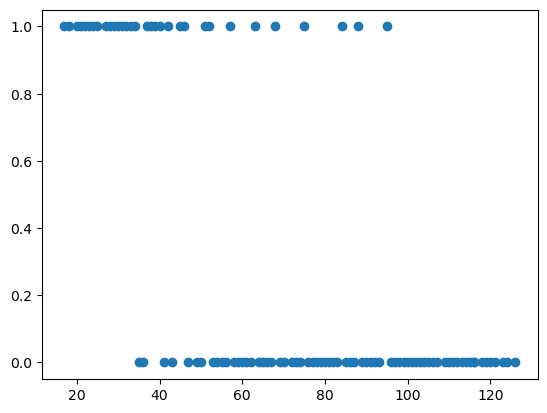

In [20]:
plt.scatter(df['miles_per_week'], df['completed_50m_ultra'])

<Axes: xlabel='completed_50m_ultra', ylabel='count'>

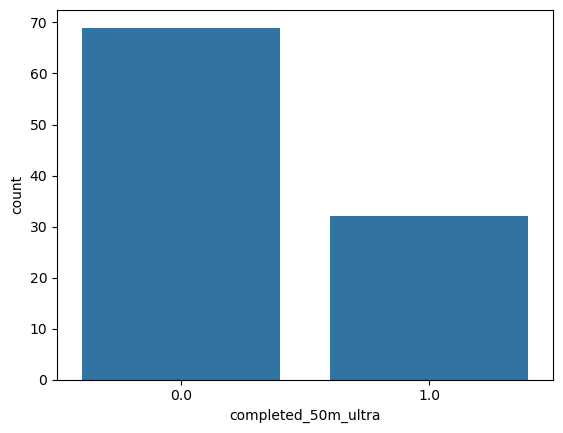

In [22]:
sns.countplot(x=df['completed_50m_ultra'], data=df)

# Train Test Split

In [23]:
X = df.drop(columns='completed_50m_ultra')
y = df['completed_50m_ultra']

X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=11, test_size = 0.2)

In [24]:
model = LogisticRegression()

In [25]:
model.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [26]:
model.score(X_test, y_test)

0.9047619047619048

In [27]:
y_pred = model.predict(X_test)

In [29]:
print(confusion_matrix(y_test, y_pred))

[[14  1]
 [ 1  5]]


In [31]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

         0.0       0.93      0.93      0.93        15
         1.0       0.83      0.83      0.83         6

    accuracy                           0.90        21
   macro avg       0.88      0.88      0.88        21
weighted avg       0.90      0.90      0.90        21

